# Name: Sophia Amsden
## BUS 458 (001) HW 2 Cyber Crime : Regression and Trees
### October 10, 2025

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve

Matplotlib is building the font cache; this may take a moment.


## Data prep

In [4]:
stolen = pd.read_csv(r"data\Stolenrecords2.csv")
crime = pd.read_csv(r"data\Crimebystate.csv", skiprows=2)
crime = crime.dropna(how="all")  
crime.columns = [
    "StateName", "Murder", "Robbery", "Assault", "Burglary", "Larceny", "Motor"
]

print(crime.head())

        StateName  Murder  Robbery  Assault  Burglary  Larceny  Motor
1  United States      5.6    140.7    291.1     726.7   2286.3  416.7
3        Alabama      8.2    141.4    247.8     953.8   2650.0  288.3
4         Alaska      4.8     80.9    465.1     622.5   2599.1  391.0
5        Arizona      7.5    144.4    327.4     948.4   2965.2  924.4
6        Arkansas     6.7     91.1    386.8    1084.6   2711.2  262.1


In [48]:
merged = pd.merge(stolen, crime, on="StateName", how="left")

## Part 1

### 1a

In [53]:
# Variables to drop
drop_cols = [
    'ExistAccountCC', 'ExistAccountOther', 'ExistAccountBank', 
    'PersonalInfo', 'NewAccount', 
    'StateName', 'zip', 'primary_city', 'country'
]


# Features (X) and target (y)
X = merged.drop(columns=['IDTheftVictim'] + drop_cols)
y = merged['IDTheftVictim']

# One-hot encode categorical columns
cat_cols = ['emp_type']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

### 1b

In [56]:
# Decision tree
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
# Fill NaN values with column mean 
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  


tree = DecisionTreeClassifier(max_depth=5, random_state=1)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=1)

In [57]:
# Fit the tree
dtree = DecisionTreeClassifier(max_depth=5, random_state=1)
dtree.fit(X_train, y_train)

# Export the tree
print(export_text(dtree, feature_names=list(X.columns)))


|--- ComputerBanking <= 0.50
|   |--- UseStrongPass <= 0.50
|   |   |--- PreauthorizedDebts <= 0.50
|   |   |   |--- ATMCard <= 0.50
|   |   |   |   |--- ChgPassReg <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- ChgPassReg >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- ATMCard >  0.50
|   |   |   |   |--- MonitorCCStmt <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- MonitorCCStmt >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- PreauthorizedDebts >  0.50
|   |   |   |--- ATMCard <= 0.50
|   |   |   |   |--- ChgPassReg <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- ChgPassReg >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- ATMCard >  0.50
|   |   |   |   |--- ChgPassReg <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- ChgPassReg >  0.50
|   |   |   |   |   |--- class: 0
|   |--- UseStrongPass >  0.50
|   |   |--- PreauthorizedDebts <= 0.50
|   |   |   |--- MonitorCCStmt <= 0.50
|   |   |   |   |---

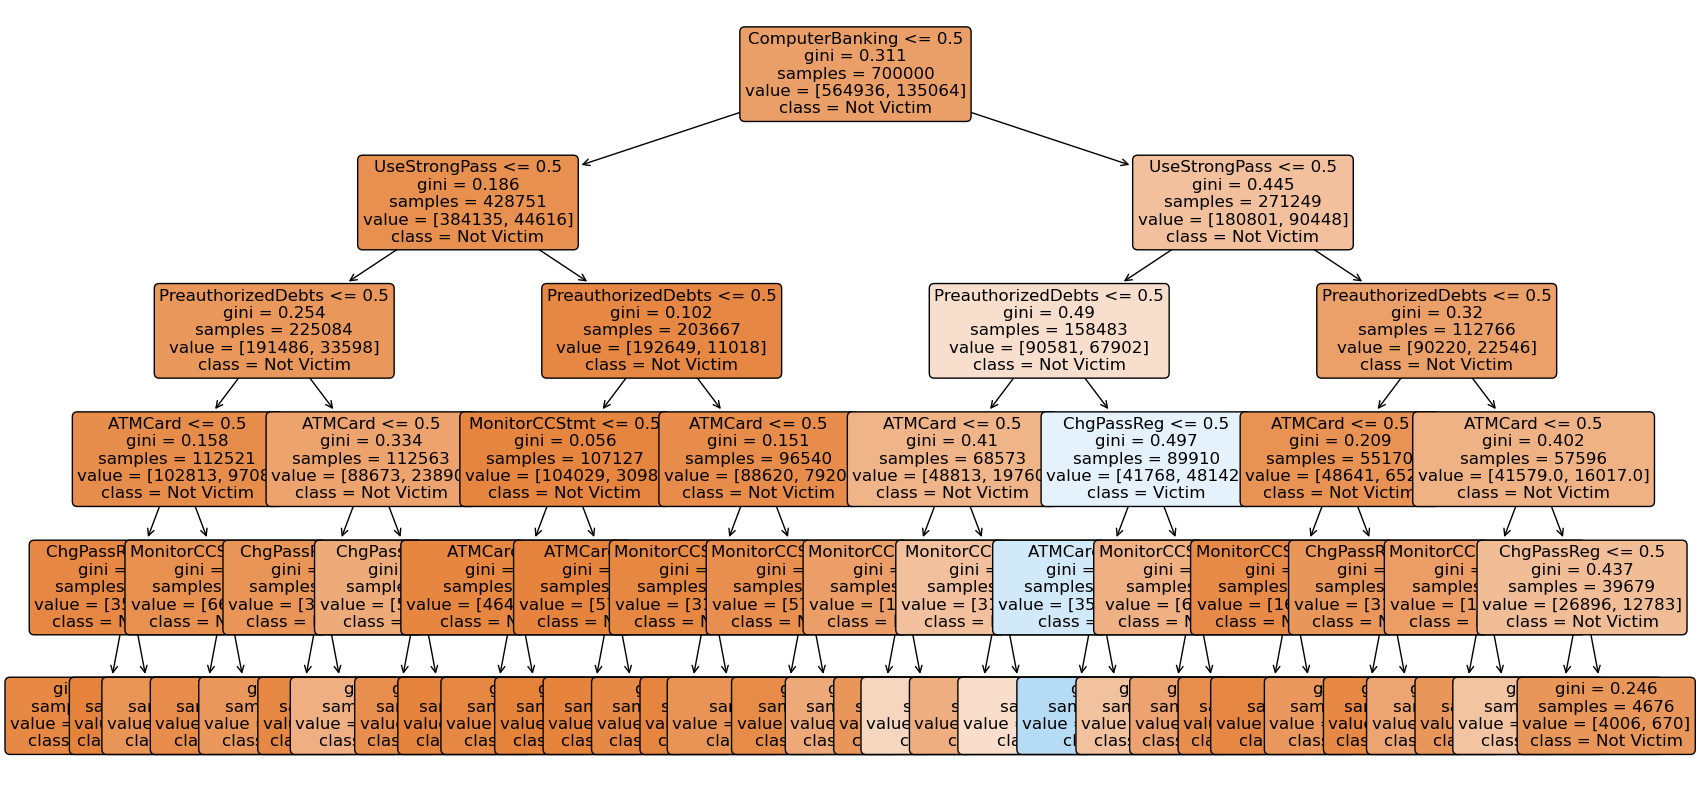

In [58]:
# Visualize decision tree
plt.figure(figsize=(20,10))  # make the figure large
plot_tree(dtree, feature_names=X.columns, class_names=['Not Victim','Victim'], 
          filled=True, rounded=True, fontsize=12)
plt.show()


### 1c

In [61]:
y_pred = dtree.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Misclassification rate
misclass_rate = 1 - accuracy_score(y_test, y_pred)
print(f"Misclassification rate: {misclass_rate:.2f}")

Confusion Matrix:
 [[232604   9730]
 [ 42047  15619]]
Misclassification rate: 0.17


### 1d

ROC AUC: 0.79


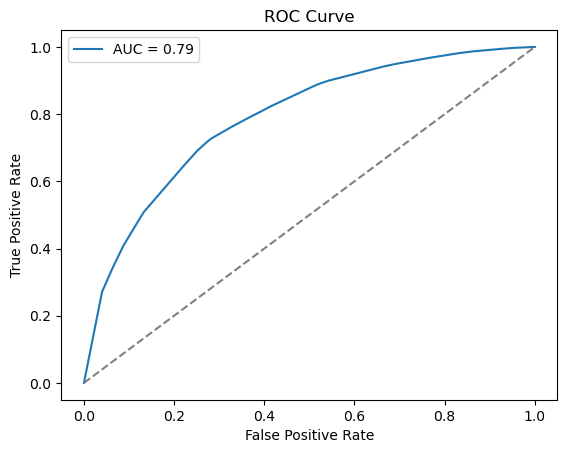

In [63]:
y_prob = dtree.predict_proba(X_test)[:,1]

# ROC AUC
auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC: {auc:.2f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')  # Random model line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### 1e

In [66]:
# Lift
df = pd.DataFrame({'y_true': y_test, 'y_prob': y_prob})

df = df.sort_values('y_prob', ascending=False)

def lift(df, portion):
    top_n = int(len(df) * portion)
    top = df.head(top_n)
    lift_value = top['y_true'].sum() / (top_n * df['y_true'].mean())
    return lift_value

lift_10 = lift(df, 0.1)
lift_20 = lift(df, 0.2)

print(f"Lift at 10%: {lift_10:.2f}")
print(f"Lift at 20%: {lift_20:.2f}")


Lift at 10%: 3.05
Lift at 20%: 2.50


## Part 2

### 2a

In [73]:
# Get top variables and coefficients
# Fit Logistic Regression
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)  # MUST come before accessing logit.coef_

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logit.coef_[0]
})

coefficients['AbsCoeff'] = coefficients['Coefficient'].abs()
coefficients.sort_values(by='AbsCoeff', ascending=False, inplace=True)
print(coefficients.head(10)) 

               Feature  Coefficient  AbsCoeff
7      ComputerBanking     1.462889  1.462889
11          ChgPassReg    -1.185618  1.185618
12       UseStrongPass    -1.108866  1.108866
5   PreauthorizedDebts     1.052021  1.052021
15   MonitorCredreport    -0.783171  0.783171
3              ATMCard     0.764670  0.764670
14       MonitorCCStmt    -0.597326  0.597326
2        DirectDeposit     0.544028  0.544028
8      InPersonBanking    -0.511347  0.511347
13     MonitorBankStmt    -0.357941  0.357941


### 2b-c

In [75]:
# Clean
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_train.mean(), inplace=True)  # Use train mean to avoid data leakage
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Fit Logistic Regression
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

y_pred_logit = logit.predict(X_test)

# Confusion matrix and misclassification rate
cm_logit = confusion_matrix(y_test, y_pred_logit)
misclass_rate_logit = 1 - accuracy_score(y_test, y_pred_logit)

print("Confusion Matrix:\n", cm_logit)
print(f"Misclassification rate: {misclass_rate_logit:.2f}")


Confusion Matrix:
 [[231952  10382]
 [ 39453  18213]]
Misclassification rate: 0.17
